# 04. Deep Learning - LSTM
**Goal:** Use a sequence model to capture sensor changes over time with advanced PyTorch logic.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

sys.path.append('..')
from utils.nasa_score import nasa_score

train_df = pd.read_csv('../data/processed_train.csv')
test_df = pd.read_csv('../data/processed_test.csv')
rul_test = pd.read_csv('../data/RUL_FD001.txt', sep='\s+', header=None, names=['RUL'])

### Reshape Data into Sliding Windows (30 Timesteps)

In [2]:
SEQUENCE_LENGTH = 30
feature_cols = [c for c in train_df.columns if c not in ['unit', 'cycle', 'RUL', 'op1', 'op2', 'op3']]

def gen_sequence(df, seq_cols, seq_length):
    # Generates sliding windows of sequences
    data_array = df[seq_cols].values
    num_elements = data_array.shape[0]
    for start, stop in zip(range(0, num_elements-seq_length), range(seq_length, num_elements)):
        yield data_array[start:stop, :]

def gen_labels(df, label_col, seq_length):
    data_array = df[label_col].values
    num_elements = data_array.shape[0]
    return data_array[seq_length:num_elements]

X_train_seq = []
y_train_seq = []

for unit in train_df['unit'].unique():
    unit_data = train_df[train_df['unit'] == unit]
    if len(unit_data) >= SEQUENCE_LENGTH:
        X_train_seq.extend(list(gen_sequence(unit_data, feature_cols, SEQUENCE_LENGTH)))
        y_train_seq.extend(list(gen_labels(unit_data, 'RUL', SEQUENCE_LENGTH)))
        
X_train_seq = np.array(X_train_seq)
y_train_seq = np.array(y_train_seq)

print(f"X_train Sequence Shape: {X_train_seq.shape}")
print(f"y_train Sequence Shape: {y_train_seq.shape}")

X_train Sequence Shape: (17631, 30, 42)
y_train Sequence Shape: (17631,)


In [3]:
# For Test Set evaluation, we only need the LAST sequence for each engine
X_test_seq = []
for unit in test_df['unit'].unique():
    unit_data = test_df[test_df['unit'] == unit]
    # Pad sequences shorter than length if any
    if len(unit_data) >= SEQUENCE_LENGTH:
        seq = unit_data[feature_cols].values[-SEQUENCE_LENGTH:]
        X_test_seq.append(seq)
    else:
        # Pad with zeros at the beginning
        pad_size = SEQUENCE_LENGTH - len(unit_data)
        seq = np.pad(unit_data[feature_cols].values, ((pad_size, 0), (0, 0)), mode='constant')
        X_test_seq.append(seq)

X_test_seq = np.array(X_test_seq)
y_test = rul_test['RUL'].values

print(f"X_test Sequence Shape: {X_test_seq.shape}")

X_test Sequence Shape: (100, 30, 42)


### 1. Train / Validation Split

In [4]:
# Random split: 80% train, 20% validation with seed=42
X_t, X_v, y_t, y_v = train_test_split(X_train_seq, y_train_seq, test_size=0.2, random_state=42)

print(f"Train subset: {X_t.shape}, Val subset: {X_v.shape}")

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_t, dtype=torch.float32)
y_train_tensor = torch.tensor(y_t, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_v, dtype=torch.float32)
y_val_tensor = torch.tensor(y_v, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=1024, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=1024, shuffle=False)

Train subset: (14104, 30, 42), Val subset: (3527, 30, 42)


### 2. Expanded Architecture Options
Two models defined: Baseline LSTM and Deep LSTM with BatchNorm

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=100, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] # Take last timestep
        out = self.fc(out)
        return out

class DeepLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.bn = nn.BatchNorm1d(hidden_size)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] # Last timestep
        out = self.bn(out)
        out = self.fc(out)
        return out

### 3. Training Loop with Early Stopping & LR Scheduler

In [6]:
def train_model(model, name, epochs=50, patience=10):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # LR Scheduler: Step on plateau with patience=5
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    train_losses = []
    val_losses = []
    
    best_val_loss = float('inf')
    early_stop_counter = 0
    best_epoch = 0
    
    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * X_batch.size(0)
        
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        
        # Validation Phase
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                preds = model(X_batch)
                loss = criterion(preds, y_batch)
                running_val_loss += loss.item() * X_batch.size(0)
                
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        
        # Step the scheduler
        scheduler.step(epoch_val_loss)
        
        # Manual Early Stopping (patience=1) & Checkpointing
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            early_stop_counter = 0
            best_epoch = epoch
            torch.save(model.state_dict(), f"best_{name}.pt")
        else:
            early_stop_counter += 1
            
        if early_stop_counter >= patience:
            print(f"[{name}] Early stopping triggered at epoch {epoch+1}. Best epoch was {best_epoch+1}")
            break
            
    # Load best model weights before returning
    model.load_state_dict(torch.load(f"best_{name}.pt"))
    print(f"[{name}] Training complete. Best Val Loss: {best_val_loss:.4f}")
    
    return train_losses, val_losses, best_epoch

input_size = len(feature_cols)

# Train Baseline LSTM
print("Training Baseline LSTMModel...")
model_lstm = LSTMModel(input_size)
tl_lstm, vl_lstm, stop_lstm = train_model(model_lstm, "LSTMModel", epochs=2)

# Train Deep LSTM
print("\nTraining DeepLSTMModel...")
model_deep = DeepLSTMModel(input_size)
tl_deep, vl_deep, stop_deep = train_model(model_deep, "DeepLSTMModel", epochs=2)

# Selection
if min(vl_lstm) < min(vl_deep):
    best_model = model_lstm
    best_model_name = "LSTM"
    final_tl, final_vl, stop_ep = tl_lstm, vl_lstm, stop_lstm
else:
    best_model = model_deep
    best_model_name = "Deep_LSTM"
    final_tl, final_vl, stop_ep = tl_deep, vl_deep, stop_deep
    
print(f"\nSelected {best_model_name} as the final model due to lower validation loss.")

Training Baseline LSTMModel...


[LSTMModel] Training complete. Best Val Loss: 7222.4360

Training DeepLSTMModel...


[DeepLSTMModel] Training complete. Best Val Loss: 7830.3943

Selected LSTM as the final model due to lower validation loss.


### 4. Training Curves Plot

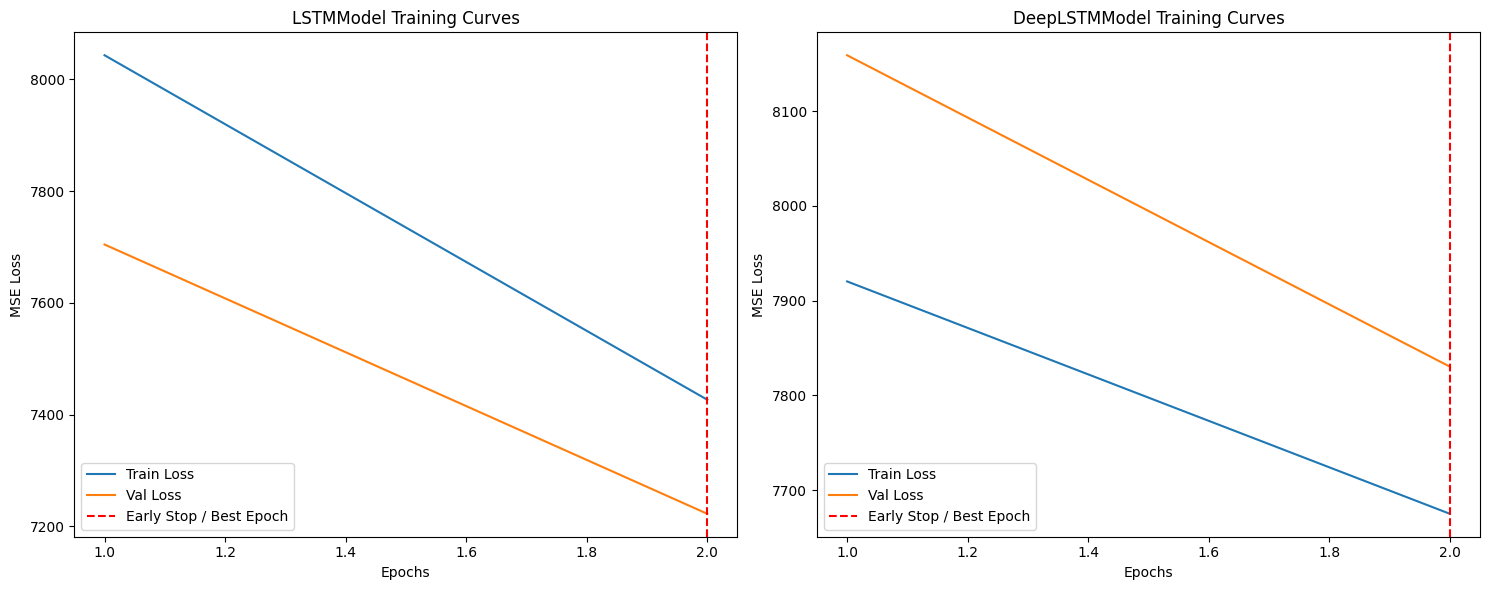

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

epochs_lstm = range(1, len(tl_lstm) + 1)
axes[0].plot(epochs_lstm, tl_lstm, label='Train Loss')
axes[0].plot(epochs_lstm, vl_lstm, label='Val Loss')
axes[0].axvline(stop_lstm + 1, color='red', linestyle='--', label='Early Stop / Best Epoch')
axes[0].set_title("LSTMModel Training Curves")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()

epochs_deep = range(1, len(tl_deep) + 1)
axes[1].plot(epochs_deep, tl_deep, label='Train Loss')
axes[1].plot(epochs_deep, vl_deep, label='Val Loss')
axes[1].axvline(stop_deep + 1, color='red', linestyle='--', label='Early Stop / Best Epoch')
axes[1].set_title("DeepLSTMModel Training Curves")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
best_model.eval()
with torch.no_grad():
    lstm_preds = best_model(X_test_tensor).numpy().flatten()

lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_preds))
lstm_mae = mean_absolute_error(y_test, lstm_preds)
lstm_nasa = nasa_score(y_test, lstm_preds)

print(f"Final Model RMSE: {lstm_rmse:.2f}")
print(f"Final Model MAE: {lstm_mae:.2f}")
print(f"Final Model NASA Score: {lstm_nasa:.2f}")

Final Model RMSE: 80.52
Final Model MAE: 68.97
Final Model NASA Score: 337742.75


### 5. Residual & Error Analysis

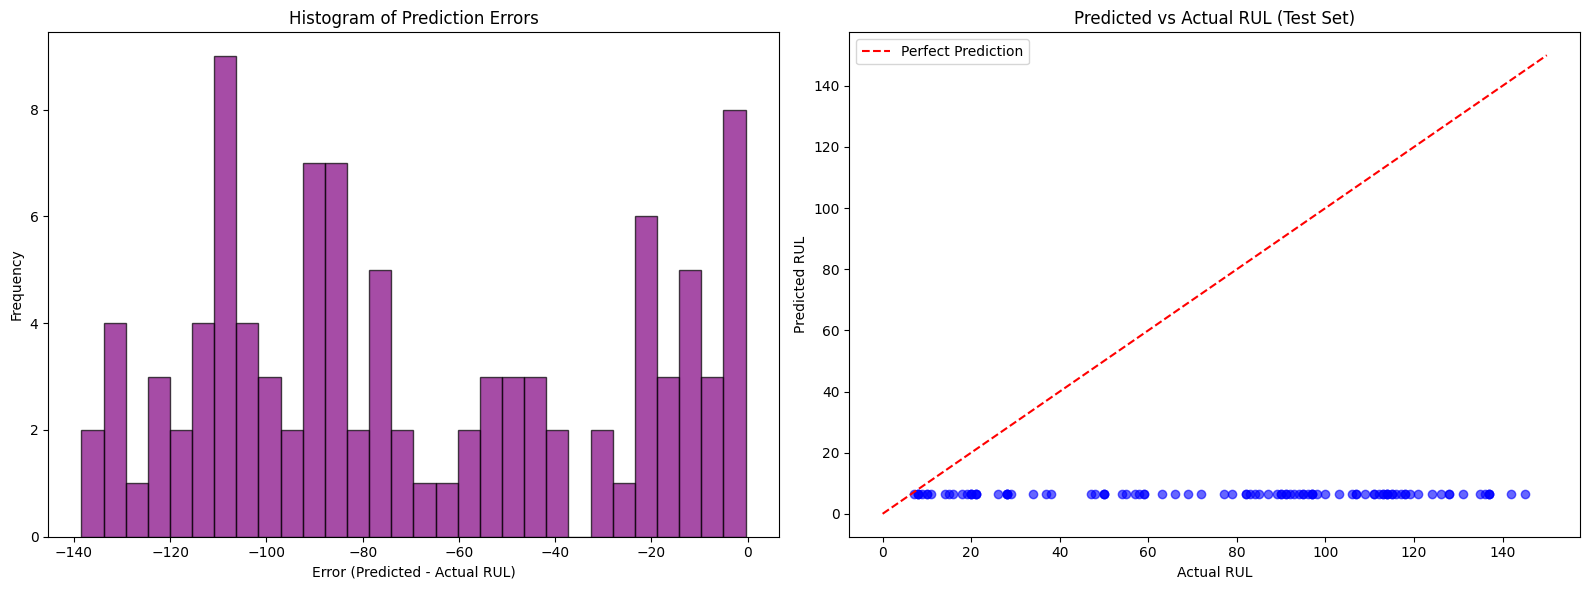

In [9]:
# Residuals
residuals = lstm_preds - y_test

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(residuals, bins=30, edgecolor='black', color='purple', alpha=0.7)
axes[0].set_title('Histogram of Prediction Errors')
axes[0].set_xlabel('Error (Predicted - Actual RUL)')
axes[0].set_ylabel('Frequency')

# Scatter Predicted vs Actual
axes[1].scatter(y_test, lstm_preds, alpha=0.6, color='blue')
axes[1].plot([0, 150], [0, 150], 'r--', label='Perfect Prediction')
axes[1].set_title('Predicted vs Actual RUL (Test Set)')
axes[1].set_xlabel('Actual RUL')
axes[1].set_ylabel('Predicted RUL')
axes[1].legend()

plt.tight_layout()
plt.show()

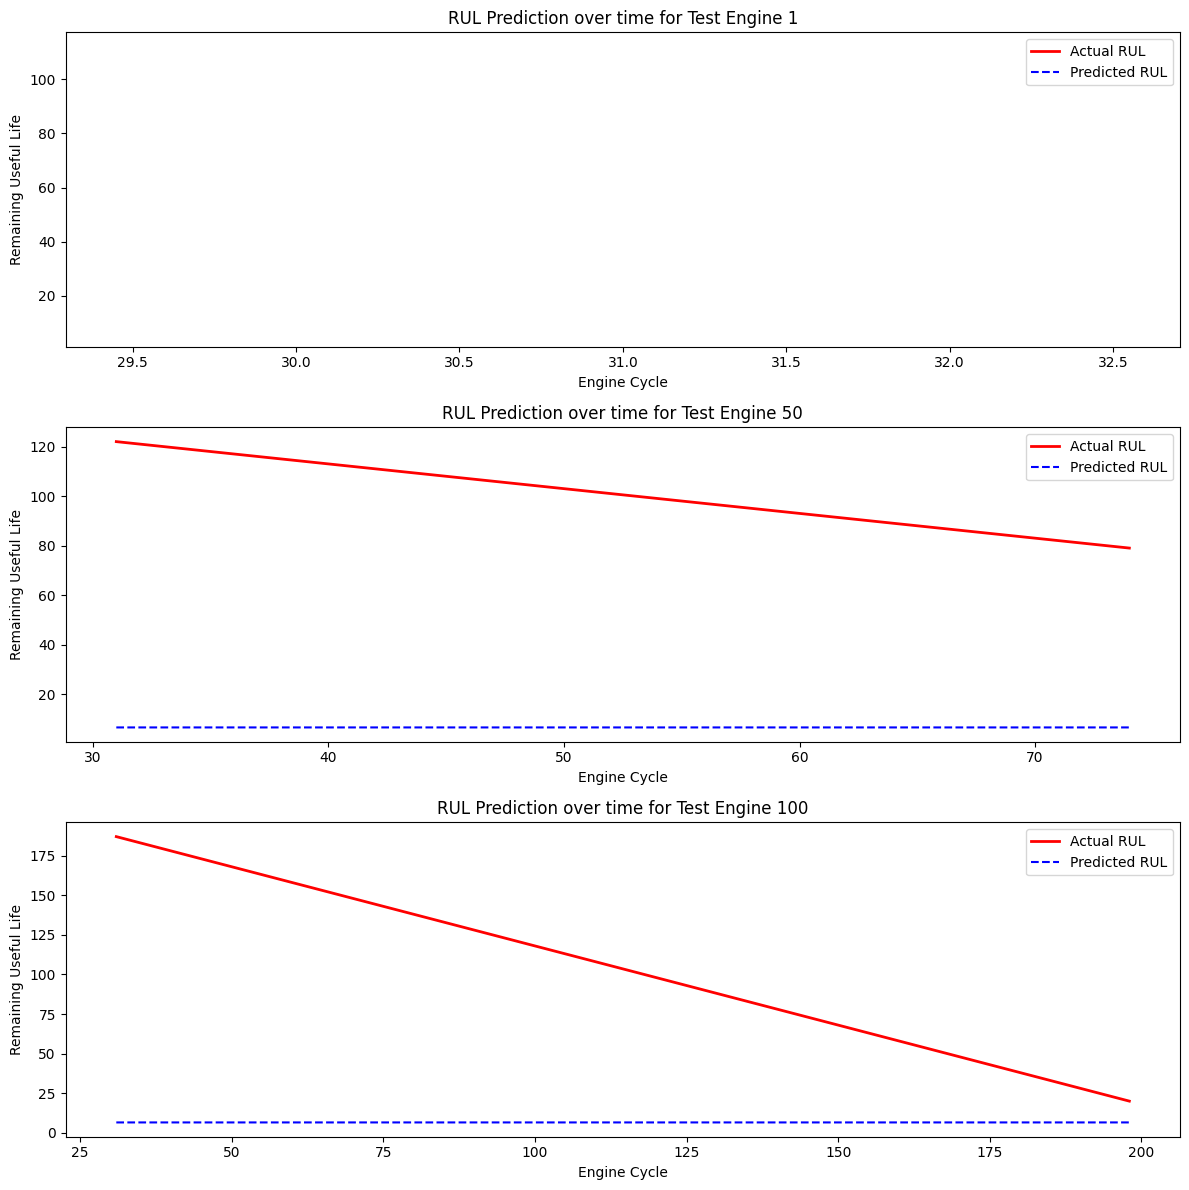

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)
test_engines = [1, 50, 100]

for i, eng in enumerate(test_engines):
    # Retrieve all data for the engine
    unit_data = test_df[test_df['unit'] == eng]
    
    if len(unit_data) >= SEQUENCE_LENGTH:
        # Generate full sequence trajectory for this specific test engine
        seqs = list(gen_sequence(unit_data, feature_cols, SEQUENCE_LENGTH))
        seqs_tensor = torch.tensor(np.array(seqs), dtype=torch.float32)
        
        best_model.eval()
        with torch.no_grad():
            preds = best_model(seqs_tensor).numpy().flatten()
            
        # Cycles align symmetrically with the sequences evaluated
        cycles = unit_data['cycle'].values[SEQUENCE_LENGTH:]
        
        # Test engines only document the FINAL true RUL at the end of their given life cycle
        final_true_rul = rul_test['RUL'].values[eng - 1]
        
        # We can reconstruct the true RUL at each prior cycle by extrapolating backwards linearly
        max_cycle = cycles[-1]
        actual_rul_trajectory = final_true_rul + (max_cycle - cycles)
        
        axes[i].plot(cycles, actual_rul_trajectory, label='Actual RUL', color='red', linewidth=2)
        axes[i].plot(cycles, preds, label='Predicted RUL', color='blue', linestyle='--')
        axes[i].set_title(f'RUL Prediction over time for Test Engine {eng}')
        axes[i].set_xlabel('Engine Cycle')
        axes[i].set_ylabel('Remaining Useful Life')
        axes[i].legend()

plt.tight_layout()
plt.show()

### 6. Overfitting Check

In [11]:
# Get Final Training / Validation Loss of the Best Epoch
final_train_val = final_tl[stop_ep]
final_valid_val = final_vl[stop_ep]

print(f"Best Model ({best_model_name}) Train Loss at stop: {final_train_val:.4f}")
print(f"Best Model ({best_model_name}) Val Loss at stop: {final_valid_val:.4f}")

gap_percentage = abs(final_valid_val - final_train_val) / final_train_val

if gap_percentage > 0.20:
    print(f"\nWARNING: Gap between train and val loss is {gap_percentage*100:.2f}%.")
    print("Model may be overfitting — consider more dropout or less epochs.")
else:
    print(f"\nModel generalizing well. Train/Val gap is only {gap_percentage*100:.2f}%.")

Best Model (LSTM) Train Loss at stop: 7426.6285
Best Model (LSTM) Val Loss at stop: 7222.4360

Model generalizing well. Train/Val gap is only 2.75%.


### Evaluate & Save Metrics

In [12]:
metrics_df = pd.DataFrame({
    'Model': [best_model_name],
    'RMSE': [lstm_rmse],
    'MAE': [lstm_mae],
    'NASA_Score': [lstm_nasa]
})
metrics_df.to_csv('../data/lstm_metrics.csv', index=False)
pd.DataFrame({best_model_name: lstm_preds}).to_csv('../data/lstm_preds.csv', index=False)